# Exploración del Data Loader — KTH Action

Este notebook explora paso a paso cómo funciona el loader de KTH Action,
desde la lectura de archivos hasta la obtención de un batch listo para el modelo.

## 0. Configuración de paths

In [1]:
import sys
import os

# Ajusta esta ruta al directorio raíz del proyecto predrnn-pytorch
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

# Ajusta esta ruta al directorio donde tienes los datos de KTH
# Estructura esperada:
#   KTH_DATA_PATH/
#     boxing/
#       person01_boxing_d1_uncomp/
#         image0001.png
#         ...
#     handclapping/
#     handwaving/
#     walking/
#     jogging/
#     running/
KTH_DATA_PATH = '/Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch/KTH'  # <-- CAMBIA ESTO

print('PROJECT_ROOT:', PROJECT_ROOT)
print('KTH_DATA_PATH:', KTH_DATA_PATH)

PROJECT_ROOT: /Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch
KTH_DATA_PATH: /Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch/KTH


## 1. Verificar estructura de carpetas del dataset

In [2]:
import os

categories = ['boxing', 'walking']

print('=== Estructura del dataset KTH ===')
for cat in categories:
    cat_path = os.path.join(KTH_DATA_PATH, cat)

    if not os.path.exists(cat_path):
        print(f'  {cat}/  [NO ENCONTRADO]')
        continue
    
    videos = sorted([v for v in os.listdir(cat_path) if os.path.isdir(os.path.join(cat_path, v))])

    print(f'  {cat}/  ({len(videos)} videos)')
    
    # Mostrar los primeros 3 videos
    for v in videos[:3]:
        v_path = os.path.join(cat_path, v)
        frames = [f for f in os.listdir(v_path) if f.startswith('image')]
        print(f'    {v}/  ({len(frames)} frames)')
    if len(videos) > 3:
        print(f'    ... y {len(videos)-3} videos más')

=== Estructura del dataset KTH ===
  boxing/  (100 videos)
    person01_boxing_d1/  (360 frames)
    person01_boxing_d2/  (390 frames)
    person01_boxing_d3/  (465 frames)
    ... y 97 videos más
  walking/  (100 videos)
    person01_walking_d1/  (555 frames)
    person01_walking_d2/  (675 frames)
    person01_walking_d3/  (950 frames)
    ... y 97 videos más


## 2. Revisar nombres de archivos y convención de nomenclatura

In [3]:
# Inspeccionar un video concreto
sample_cat  = 'boxing'
sample_path = os.path.join(KTH_DATA_PATH, sample_cat)
sample_vid  = sorted([v for v in os.listdir(sample_path) if os.path.isdir(os.path.join(sample_path, v))])[0]
vid_path    = os.path.join(sample_path, sample_vid)

frames = sorted([f for f in os.listdir(vid_path) if f.startswith('image')])

print(f'Video: {sample_vid}')
print(f'Total frames: {len(frames)}')
print(f'Primeros 5 frames: {frames[:5]}')
print(f'Últimos 5 frames:  {frames[-5:]}')

# Extraer el número de frame como hace el código
print('\nExtracción del número (chars 6-10 del nombre):')
for f in frames[:5]:
    num = int(f[6:9])
    print(f'  {f}  ->  {num}')

# Extraer person ID como hace el código (chars 6-7 del nombre de carpeta)
person_id = sample_vid[6:8]
print(f'\nPerson ID extraído de "{sample_vid}": "{person_id}"')

Video: person01_boxing_d1
Total frames: 360
Primeros 5 frames: ['image-001.png', 'image-002.png', 'image-003.png', 'image-004.png', 'image-005.png']
Últimos 5 frames:  ['image-356.png', 'image-357.png', 'image-358.png', 'image-359.png', 'image-360.png']

Extracción del número (chars 6-10 del nombre):
  image-001.png  ->  1
  image-002.png  ->  2
  image-003.png  ->  3
  image-004.png  ->  4
  image-005.png  ->  5

Person ID extraído de "person01_boxing_d1": "01"


## 3. Leer y visualizar un frame individual

Imagen original:  shape=(128, 128)  dtype=uint8  min=17  max=224
Tras resize:      shape=(128, 128)
Tras normalizar:  shape=(128, 128)  dtype=float32  min=0.067  max=0.878


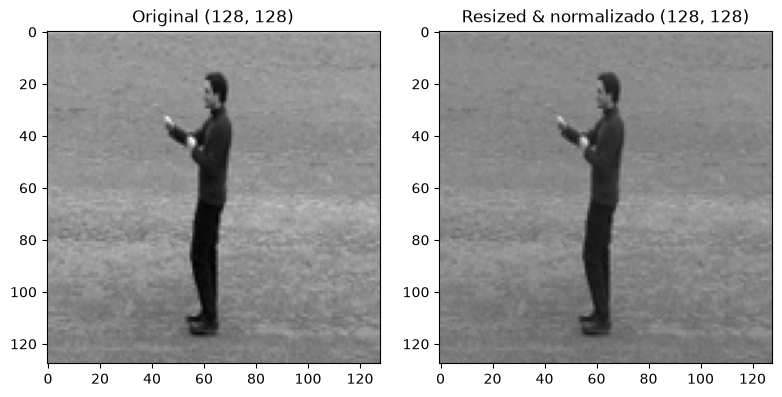

In [4]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_WIDTH = 128  # tamaño al que se redimensiona (ajusta según tus experimentos)

frame_path = os.path.join(vid_path, frames[0])

# --- Así lo hace el loader ---
frame_im = Image.open(frame_path).convert('L')      # PIL, escala de grises
frame_np = np.array(frame_im, dtype=np.uint8)       # numpy uint8 2D
frame_resized = cv2.resize(frame_np, (IMAGE_WIDTH, IMAGE_WIDTH))  # resize cuadrado
frame_float   = (frame_resized / 255.0).astype(np.float32)        # normalizar [0,1]

print(f'Imagen original:  shape={frame_np.shape}  dtype={frame_np.dtype}  min={frame_np.min()}  max={frame_np.max()}')
print(f'Tras resize:      shape={frame_resized.shape}')
print(f'Tras normalizar:  shape={frame_float.shape}  dtype={frame_float.dtype}  min={frame_float.min():.3f}  max={frame_float.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(frame_np, cmap='gray')
axes[0].set_title(f'Original {frame_np.shape}')
axes[1].imshow(frame_float, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Resized & normalizado {frame_float.shape}')
plt.tight_layout()
plt.show()

## 4. Instanciar `DataProcess` y cargar los datos

In [5]:
from core.data_provider import kth_action

SEQ_LENGTH = 20  # total de frames por secuencia (input + predicción)
BATCH_SIZE  = 4

input_param = {
    'paths':           [KTH_DATA_PATH],
    'image_width':     IMAGE_WIDTH,
    'minibatch_size':  BATCH_SIZE,
    'seq_length':      SEQ_LENGTH,
    'input_data_type': 'float32',
    'name':            'kth_explorer'
}

print('Instanciando DataProcess...')
data_process = kth_action.DataProcess(input_param)
print('OK. Categorías:', data_process.categories)
print('Train personas:', data_process.train_person)
print('Test  personas:', data_process.test_person)

Instanciando DataProcess...
OK. Categorías: ['boxing', 'running']
Train personas: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16']
Test  personas: ['17', '18', '19', '20', '21', '22', '23', '24', '25']


## 5. Explorar `generate_frames` — iteración sobre frames individuales

In [6]:
# generate_frames es un generador: yield ActionFrameInfo por cada frame
# Inspeccionamos los primeros 10
print('Primeros 10 ActionFrameInfo del split train:')
for i, frame_info in enumerate(data_process.generate_frames(KTH_DATA_PATH, data_process.train_person)):
    print(f'  [{i:3d}] person_mark={frame_info.person_mark:3d}  '
          f'category={frame_info.category_flag}  '
          f'file={frame_info.file_name}  '
          f'path=.../{os.path.basename(os.path.dirname(frame_info.file_path))}/{frame_info.file_name}')
    if i >= 9:
        break

Primeros 10 ActionFrameInfo del split train:
  [  0] person_mark=  1  category=1  file=image-001.png  path=.../person16_boxing_d4/image-001.png
  [  1] person_mark=  1  category=1  file=image-002.png  path=.../person16_boxing_d4/image-002.png
  [  2] person_mark=  1  category=1  file=image-003.png  path=.../person16_boxing_d4/image-003.png
  [  3] person_mark=  1  category=1  file=image-004.png  path=.../person16_boxing_d4/image-004.png
  [  4] person_mark=  1  category=1  file=image-005.png  path=.../person16_boxing_d4/image-005.png
  [  5] person_mark=  1  category=1  file=image-006.png  path=.../person16_boxing_d4/image-006.png
  [  6] person_mark=  1  category=1  file=image-007.png  path=.../person16_boxing_d4/image-007.png
  [  7] person_mark=  1  category=1  file=image-008.png  path=.../person16_boxing_d4/image-008.png
  [  8] person_mark=  1  category=1  file=image-009.png  path=.../person16_boxing_d4/image-009.png
  [  9] person_mark=  1  category=1  file=image-010.png  path=..

In [7]:
# Contar el total de frames que se van a cargar en train
total_train = sum(1 for _ in data_process.generate_frames(KTH_DATA_PATH, data_process.train_person))
total_test  = sum(1 for _ in data_process.generate_frames(KTH_DATA_PATH, data_process.test_person))
print(f'Total frames train: {total_train}')
print(f'Total frames test:  {total_test}')

Total frames train: 54545
Total frames test:  29147


## 6. `load_data` — carga completa a RAM

In [8]:
# load_data carga TODOS los frames en un único array numpy y extrae los índices de secuencias
print('Cargando datos de TRAIN en RAM...')
train_data, train_indices = data_process.load_data([KTH_DATA_PATH], mode='train')

print(f'\ntrain_data shape:   {train_data.shape}   <- [N_frames, H, W, 1]')
print(f'train_data dtype:   {train_data.dtype}')
print(f'train_data min/max: {train_data.min():.3f} / {train_data.max():.3f}')
print(f'\ntrain_indices:      {len(train_indices)} secuencias válidas')
print(f'Primeros 5 índices de inicio de secuencia: {train_indices[:5]}')

Cargando datos de TRAIN en RAM...
begin load data/Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch/KTH
Preparing to load 54545 video frames.
there are 54545 pictures
there are 9309 sequences

train_data shape:   (54545, 128, 128, 1)   <- [N_frames, H, W, 1]
train_data dtype:   float32
train_data min/max: 0.000 / 1.000

train_indices:      9309 secuencias válidas
Primeros 5 índices de inicio de secuencia: [54525, 54522, 54519, 54516, 54513]


In [9]:
# Memoria aproximada del array
mb = train_data.nbytes / 1024**2
print(f'Memoria del array train_data: {mb:.1f} MB')

Memoria del array train_data: 3409.1 MB


## 7. Instanciar `InputHandle` directamente y explorar su estado

In [10]:
# InputHandle recibe el array de datos, los índices de secuencias y el input_param
train_handle = kth_action.InputHandle(train_data, train_indices, input_param)

print('InputHandle creado')
print(f'  total secuencias: {train_handle.total()}')
print(f'  minibatch_size:   {train_handle.minibatch_size}')
print(f'  seq_length:       {train_handle.current_input_length}')
print(f'  image_width:      {train_handle.image_width}')

InputHandle creado
  total secuencias: 9309
  minibatch_size:   4
  seq_length:       20
  image_width:      128


## 8. `begin()` — inicializar la iteración

In [11]:
# begin() mezcla los índices (shuffle) y posiciona en el primer batch
train_handle.begin(do_shuffle=True)

print(f'current_position:       {train_handle.current_position}')
print(f'current_batch_indices:  {train_handle.current_batch_indices}  <- índices de las secuencias del 1er batch')
print(f'no_batch_left():        {train_handle.no_batch_left()}')

current_position:       0
current_batch_indices:  [5200, 52971, 46902, 50039]  <- índices de las secuencias del 1er batch
no_batch_left():        False


## 9. `get_batch()` — obtener el primer batch

In [12]:
batch = train_handle.get_batch()

print(f'batch shape: {batch.shape}   <- [B, T, H, W, C]')
print(f'  B = batch_size  = {batch.shape[0]}')
print(f'  T = seq_length  = {batch.shape[1]}')
print(f'  H = img_height  = {batch.shape[2]}')
print(f'  W = img_width   = {batch.shape[3]}')
print(f'  C = channels    = {batch.shape[4]}  (1 = escala de grises)')
print(f'dtype: {batch.dtype}')
print(f'min / max: {batch.min():.4f} / {batch.max():.4f}')

batch shape: (4, 20, 128, 128, 1)   <- [B, T, H, W, C]
  B = batch_size  = 4
  T = seq_length  = 20
  H = img_height  = 128
  W = img_width   = 128
  C = channels    = 1  (1 = escala de grises)
dtype: float32
min / max: 0.0118 / 1.0000


## 10. Visualizar las secuencias del batch

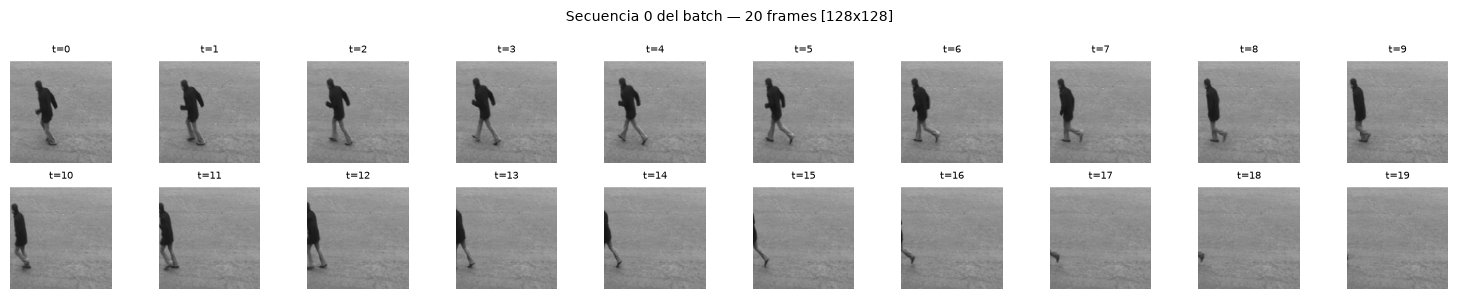

In [20]:
# Mostrar todos los frames del primer video del batch
sample_video = batch[2]  # [T, H, W, 1]

cols = 10
rows = (SEQ_LENGTH + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
axes = axes.flatten()

for t in range(SEQ_LENGTH):
    axes[t].imshow(sample_video[t, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[t].set_title(f't={t}', fontsize=7)
    axes[t].axis('off')

for ax in axes[SEQ_LENGTH:]:
    ax.axis('off')

plt.suptitle(f'Secuencia 0 del batch — {SEQ_LENGTH} frames [{IMAGE_WIDTH}x{IMAGE_WIDTH}]', fontsize=10)
plt.tight_layout()
plt.show()

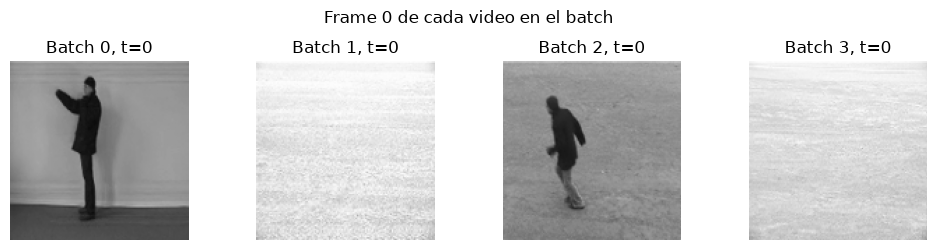

In [14]:
# Comparar los 4 videos del batch (primer frame de cada uno)
fig, axes = plt.subplots(1, BATCH_SIZE, figsize=(BATCH_SIZE * 2.5, 2.5))
for b in range(BATCH_SIZE):
    axes[b].imshow(batch[b, 0, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[b].set_title(f'Batch {b}, t=0')
    axes[b].axis('off')
plt.suptitle('Frame 0 de cada video en el batch')
plt.tight_layout()
plt.show()

## 11. Iterar sobre batches con `next()`

In [15]:
train_handle.begin(do_shuffle=False)

n_batches = 0
while not train_handle.no_batch_left():
    b = train_handle.get_batch()
    n_batches += 1
    train_handle.next()

total_seqs = train_handle.total()
print(f'Total secuencias: {total_seqs}')
print(f'Total batches (batch_size={BATCH_SIZE}): {n_batches}')
print(f'Secuencias procesadas: {n_batches * BATCH_SIZE} '
      f'({total_seqs - n_batches * BATCH_SIZE} descartadas al final si no completan un batch)')

Total secuencias: 9309
Total batches (batch_size=4): 2327
Secuencias procesadas: 9308 (1 descartadas al final si no completan un batch)


## 12. Usar el helper completo `get_train_input_handle` / `get_test_input_handle`

In [16]:
# Esta es la forma que usa datasets_factory internamente
print('Obteniendo handle de TRAIN...')
train_handle2 = data_process.get_train_input_handle()
train_handle2.begin(do_shuffle=True)

print('Obteniendo handle de TEST...')
test_handle = data_process.get_test_input_handle()
test_handle.begin(do_shuffle=False)

print(f'\nTrain: {train_handle2.total()} secuencias')
print(f'Test:  {test_handle.total()} secuencias')

batch_test = test_handle.get_batch()
print(f'\nPrimer batch de TEST shape: {batch_test.shape}')

Obteniendo handle de TRAIN...
begin load data/Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch/KTH
Preparing to load 54545 video frames.
there are 54545 pictures
there are 9309 sequences
Obteniendo handle de TEST...
begin load data/Users/emilioespinosa/Documents/DMREF_Project/Codigo/predrnn-pytorch/KTH
Preparing to load 29147 video frames.
there are 29147 pictures
there are 4935 sequences

Train: 9309 secuencias
Test:  4935 secuencias

Primer batch de TEST shape: (4, 20, 128, 128, 1)


## 13. Paso completo: loader → reshape_patch → listo para el modelo

In [17]:
from core.utils import preprocess

PATCH_SIZE  = 4
IMG_CHANNEL = 1

train_handle2.begin(do_shuffle=True)
raw_batch = train_handle2.get_batch()   # [B, T, H, W, C]

# Paso 1: reshape_patch — reduce resolución espacial, expande canales
patch_batch = preprocess.reshape_patch(raw_batch, PATCH_SIZE)

H_patch = IMAGE_WIDTH // PATCH_SIZE
C_patch = PATCH_SIZE * PATCH_SIZE * IMG_CHANNEL

print('=== Pipeline completo ===')
print(f'raw_batch shape:   {raw_batch.shape}')
print(f'  [B={BATCH_SIZE}, T={SEQ_LENGTH}, H={IMAGE_WIDTH}, W={IMAGE_WIDTH}, C={IMG_CHANNEL}]')
print()
print(f'patch_batch shape: {patch_batch.shape}')
print(f'  [B={BATCH_SIZE}, T={SEQ_LENGTH}, H_p={H_patch}, W_p={H_patch}, C_p={C_patch}]')
print(f'  (patch_size={PATCH_SIZE} → H/{PATCH_SIZE}={H_patch}, patch_size²×C={C_patch})')
print()
print('Este es el tensor que entra al modelo PredRNN v2 (frames_tensor).')

# Verificar que reshape_patch_back es la inversa exacta
recovered = preprocess.reshape_patch_back(patch_batch, PATCH_SIZE)
print(f'\nrecovered shape:   {recovered.shape}  <- debe coincidir con raw_batch')
print(f'Error máximo tras round-trip: {np.abs(raw_batch - recovered).max():.2e}  <- debe ser 0')

=== Pipeline completo ===
raw_batch shape:   (4, 20, 128, 128, 1)
  [B=4, T=20, H=128, W=128, C=1]

patch_batch shape: (4, 20, 32, 32, 16)
  [B=4, T=20, H_p=32, W_p=32, C_p=16]
  (patch_size=4 → H/4=32, patch_size²×C=16)

Este es el tensor que entra al modelo PredRNN v2 (frames_tensor).

recovered shape:   (4, 20, 128, 128, 1)  <- debe coincidir con raw_batch
Error máximo tras round-trip: 0.00e+00  <- debe ser 0


## 14. Estadísticas globales del dataset

=== Estadísticas del array train_data ===
shape:       (54545, 128, 128, 1)
dtype:       float32
min:         0.0000
max:         1.0000
mean:        0.6154
std:         0.1947


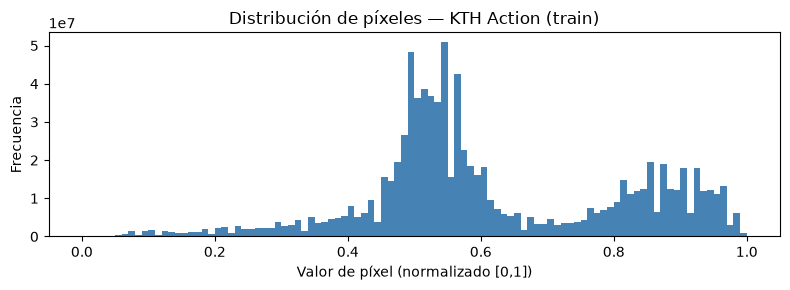

In [18]:
# Estadísticas sobre el array completo de frames de train
print('=== Estadísticas del array train_data ===')
print(f'shape:       {train_data.shape}')
print(f'dtype:       {train_data.dtype}')
print(f'min:         {train_data.min():.4f}')
print(f'max:         {train_data.max():.4f}')
print(f'mean:        {train_data.mean():.4f}')
print(f'std:         {train_data.std():.4f}')

# Histograma de valores de píxel
plt.figure(figsize=(8, 3))
plt.hist(train_data.flatten(), bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Valor de píxel (normalizado [0,1])')
plt.ylabel('Frecuencia')
plt.title('Distribución de píxeles — KTH Action (train)')
plt.tight_layout()
plt.show()